# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib
import warnings
warnings.filterwarnings('ignore')


# Load Data

In [4]:
df = pd.read_csv('../data/wshg_loan_data.csv')


print(df.shape)
print(df.info())
df.head()


(1200, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan_ID                    1200 non-null   object 
 1   Group_ID                   1200 non-null   object 
 2   Group_Size                 1200 non-null   int64  
 3   Years_in_Group             1200 non-null   int64  
 4   Group_Savings              1200 non-null   float64
 5   Group_Loan_Repayment_Rate  1200 non-null   float64
 6   Meeting_Attendance_Pct     1200 non-null   float64
 7   Gender                     1200 non-null   object 
 8   Married                    1164 non-null   object 
 9   Dependents                 1164 non-null   object 
 10  Education                  1200 non-null   object 
 11  Self_Employed              1164 non-null   object 
 12  ApplicantIncome            1200 non-null   int64  
 13  CoapplicantIncome          1200 non-n

,Loan_ID,Group_ID,Group_Size,Years_in_Group,Group_Savings,Group_Loan_Repayment_Rate,Meeting_Attendance_Pct,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,WSHG0103,17,4,28341.31,0.71,59.5,Female,Yes,0,Not Graduate,Yes,4042,2379,103.0,360,1.0,Rural,Y
1,LP000002,WSHG0180,14,4,55784.05,0.69,91.1,Female,Yes,3+,Not Graduate,No,2178,3603,283.0,300,0.0,Rural,N
2,LP000003,WSHG0093,13,7,50433.44,0.67,77.2,Female,No,NaN,Graduate,No,6866,982,47.0,240,0.0,Urban,N
3,LP000004,WSHG0015,11,8,32344.53,0.93,53.9,Female,Yes,0,Graduate,No,11581,3942,72.0,360,1.0,Semiurban,Y
4,LP000005,WSHG0107,12,1,21341.94,0.71,97.8,Female,Yes,1,Graduate,Yes,7143,2590,79.0,240,0.0,Rural,N


# Data Cleaning & Preprocessing

In [5]:
df['Dependents'] = df['Dependents'].replace('3+', 4)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')
print(df['Dependents'].unique())


[ 0.  4. nan  1.  2.]


In [6]:
print(df.isnull().sum())

Loan_ID                       0
Group_ID                      0
Group_Size                    0
Years_in_Group                0
Group_Savings                 0
Group_Loan_Repayment_Rate     0
Meeting_Attendance_Pct        0
Gender                        0
Married                      36
Dependents                   36
Education                     0
Self_Employed                36
ApplicantIncome               0
CoapplicantIncome             0
LoanAmount                   36
Loan_Amount_Term              0
Credit_History               36
Property_Area                 0
Loan_Status                   0
dtype: int64


In [7]:
cat_cols = ['Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

num_cols = ['LoanAmount']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Loan_ID                      0
Group_ID                     0
Group_Size                   0
Years_in_Group               0
Group_Savings                0
Group_Loan_Repayment_Rate    0
Meeting_Attendance_Pct       0
Gender                       0
Married                      0
Dependents                   0
Education                    0
Self_Employed                0
ApplicantIncome              0
CoapplicantIncome            0
LoanAmount                   0
Loan_Amount_Term             0
Credit_History               0
Property_Area                0
Loan_Status                  0
dtype: int64


# Feature Engineering

In [8]:
df['Total_Income']        = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Loan_Income_Ratio']   = df['LoanAmount'] / (df['Total_Income'] + 1)
df['Group_Strength_Score'] = (
    df['Group_Savings'] / 10000 +
    df['Group_Loan_Repayment_Rate'] * 10 +
    df['Years_in_Group'] * 0.5 +
    df['Meeting_Attendance_Pct'] / 20
).round(2)

print(df[['Total_Income', 'Loan_Income_Ratio', 'Group_Strength_Score']].head())


   Total_Income  Loan_Income_Ratio  Group_Strength_Score
0          6421           0.016039                 14.91
1          5781           0.048945                 19.03
2          7848           0.005988                 19.10
3         15523           0.004638                 19.23
4          9733           0.008116                 14.62


# Exploratory Data Analysis (EDA)

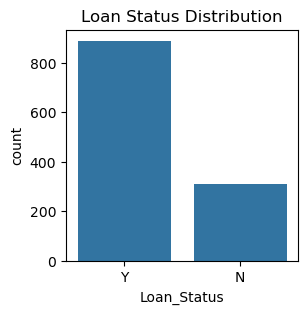

In [21]:
plt.figure(figsize=(3, 3))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()


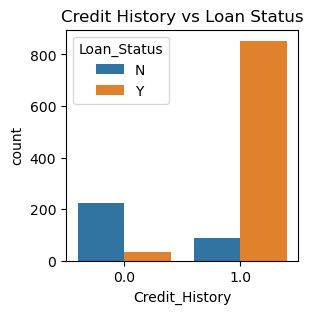

In [22]:
plt.figure(figsize=(3,3))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()


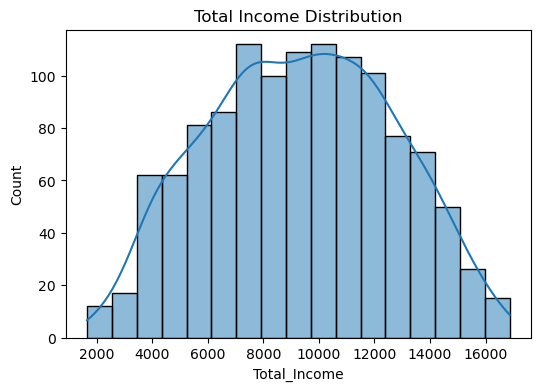

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['Total_Income'], kde=True)
plt.title('Total Income Distribution')
plt.show()


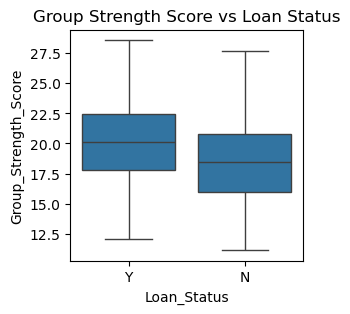

In [25]:
plt.figure(figsize=(3,3))
sns.boxplot(x='Loan_Status', y='Group_Strength_Score', data=df)
plt.title('Group Strength Score vs Loan Status')
plt.show()


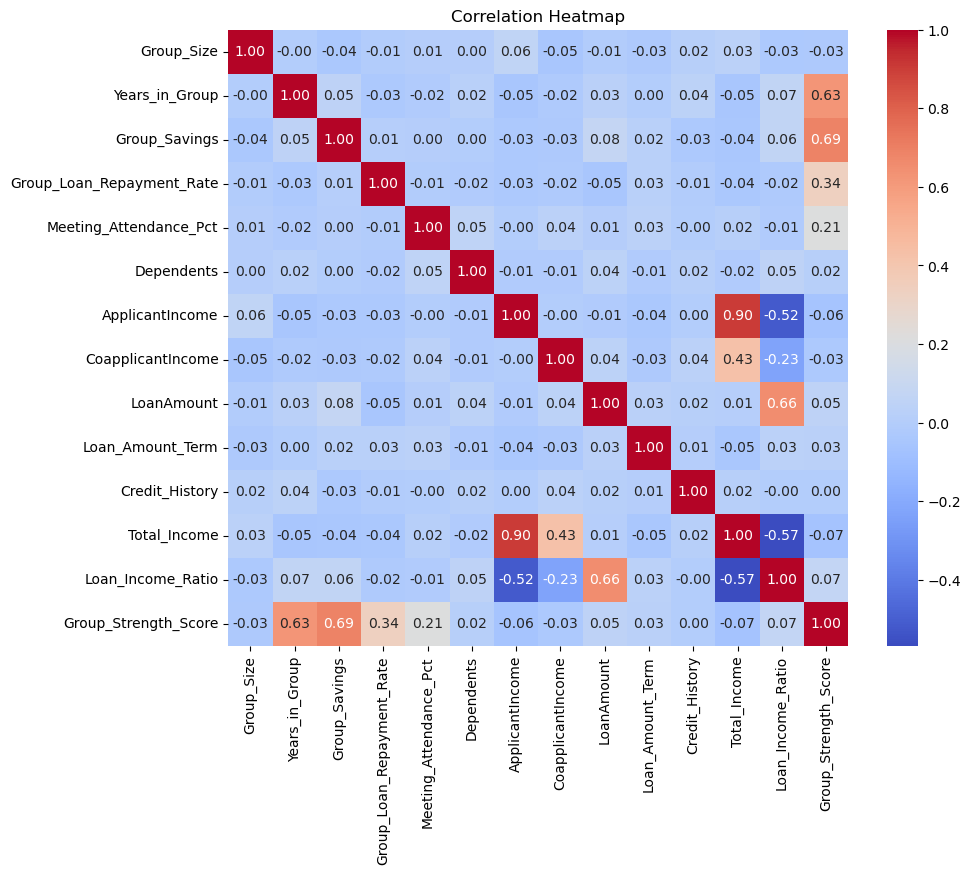

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Encoding & Feature Selection

In [30]:
le = LabelEncoder()
categorical_columns = ['Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))


In [31]:
X = df.drop(['Loan_Status', 'Loan_ID', 'Group_ID', 'Gender'], axis=1)
y = df['Loan_Status']

print("Features used:", X.columns.tolist())
print("Shape:", X.shape)


Features used: ['Group_Size', 'Years_in_Group', 'Group_Savings', 'Group_Loan_Repayment_Rate', 'Meeting_Attendance_Pct', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Total_Income', 'Loan_Income_Ratio', 'Group_Strength_Score']
Shape: (1200, 18)


# Train-Test Split & Scaling

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (960, 18)
Test size:  (240, 18)


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Model Training

In [35]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9041666666666667


In [36]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8833333333333333


In [37]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9


In [38]:
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print('SVM Accuracy:', accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9083333333333333


# Hyperparameter Tuning — All Models

In [39]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}
lr_grid = GridSearchCV(LogisticRegression(), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print("LR  Best Params :", lr_grid.best_params_)
print("LR  Best CV Score:", round(lr_grid.best_score_, 4))

LR  Best Params : {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
LR  Best CV Score: 0.9


In [40]:
dt_params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print("DT  Best Params :", dt_grid.best_params_)
print("DT  Best CV Score:", round(dt_grid.best_score_, 4))

DT  Best Params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
DT  Best CV Score: 0.8927


In [41]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("RF  Best Params :", rf_grid.best_params_)
print("RF  Best CV Score:", round(rf_grid.best_score_, 4))

RF  Best Params : {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}
RF  Best CV Score: 0.901


In [42]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

print("SVM Best Params :", svm_grid.best_params_)
print("SVM Best CV Score:", round(svm_grid.best_score_, 4))

SVM Best Params : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best CV Score: 0.8969


# Performance Metrics — All Tuned Models

In [43]:
lr_best_pred  = lr_grid.best_estimator_.predict(X_test_scaled)
dt_best_pred  = dt_grid.best_estimator_.predict(X_test)
rf_best_pred  = rf_grid.best_estimator_.predict(X_test)
svm_best_pred = svm_grid.best_estimator_.predict(X_test_scaled)

tuned_preds = {
    'Logistic Regression': lr_best_pred,
    'Decision Tree':       dt_best_pred,
    'Random Forest':       rf_best_pred,
    'SVM':                 svm_best_pred
}

rows = []
for name, preds in tuned_preds.items():
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, preds, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, preds, zero_division=0), 4),
    })

results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9042     0.9101  0.9663    0.9373
Decision Tree          0.8917     0.8800  0.9888    0.9312
Random Forest          0.8917     0.8958  0.9663    0.9297
SVM                    0.9083     0.9062  0.9775    0.9405


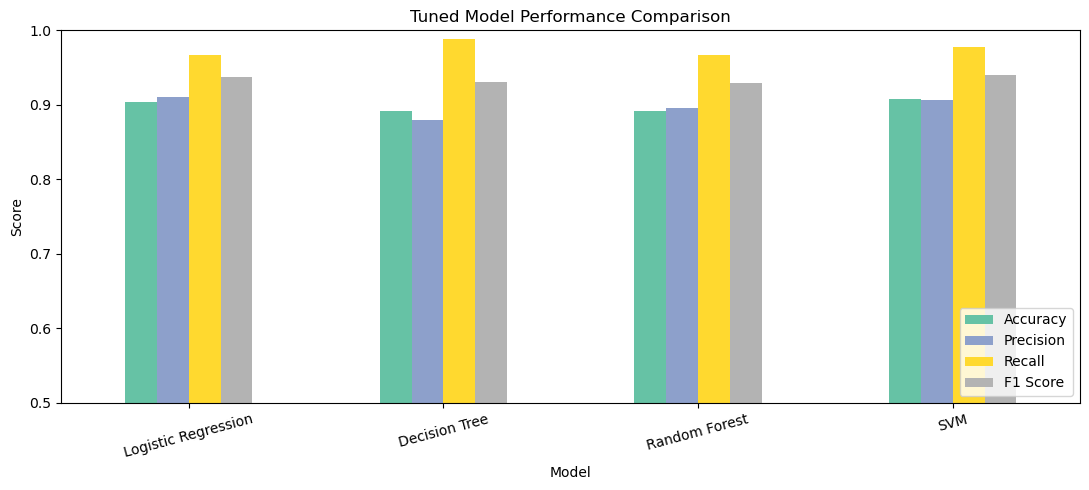

In [44]:
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(11, 5), colormap='Set2', rot=15
)
plt.title('Tuned Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

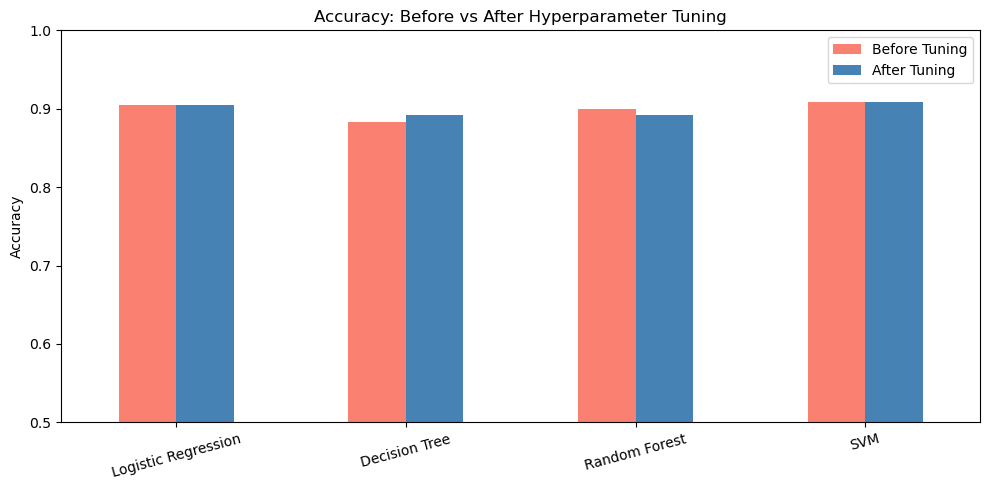

In [45]:
before = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Decision Tree':       accuracy_score(y_test, dt_pred),
    'Random Forest':       accuracy_score(y_test, rf_pred),
    'SVM':                 accuracy_score(y_test, svm_pred)
}
after = {name: results_df.loc[name, 'Accuracy'] for name in before}

compare_df = pd.DataFrame({'Before Tuning': before, 'After Tuning': after})
compare_df.plot(kind='bar', figsize=(10, 5), color=['salmon', 'steelblue'], rot=15)
plt.title('Accuracy: Before vs After Hyperparameter Tuning')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

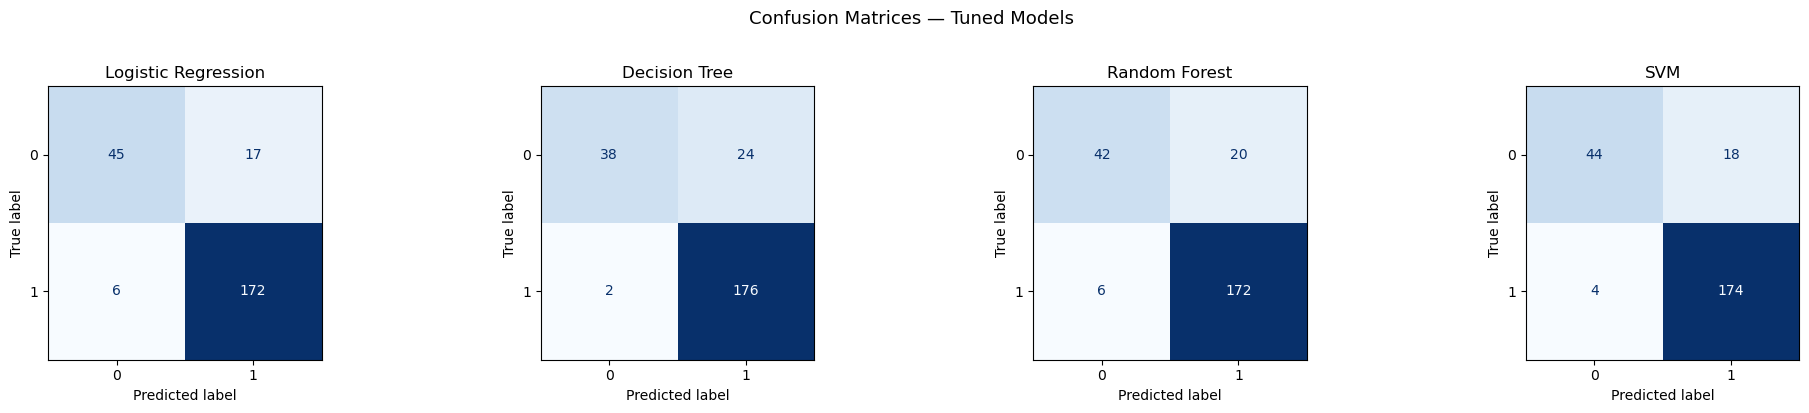

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, preds) in zip(axes, tuned_preds.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Model Selection

In [51]:
best_by_f1 = results_df['F1 Score'].idxmax()

print("MODEL SELECTION SUMMARY")

print(f"Best by F1 Score : {best_by_f1}")

MODEL SELECTION SUMMARY
Best by F1 Score : SVM


# Save Best Model

In [53]:
best_estimators = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Decision Tree':       dt_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'SVM':                 svm_grid.best_estimator_
}

# Select best model based on F1 Score
best_model_obj = best_estimators[best_by_f1]

# Save model
joblib.dump(best_model_obj, '../models/wshg_best_model.joblib')

print(f"Best model '{best_by_f1}' saved → ../models/wshg_best_model.joblib")

Best model 'SVM' saved → ../models/wshg_best_model.joblib
